In [2]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../olimpics.zip")
df

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,No medal
...,...,...,...,...,...,...,...,...,...,...,...
252560,4986655,Sefora Ada,F,Equatorial Guinea,GEQ,2024,Summer,Paris,Athletics,Women's 100m,No medal
252561,9460001,Emanuela Liuzzi,F,Italy,ITA,2024,Summer,Paris,Wrestling,Women's Freestyle 50kg,No medal
252562,1972077,Isayah Boers,M,Netherlands,NED,2024,Summer,Paris,Athletics,4 x 400m Relay Mixed,Gold
252563,1899865,Kevin Staut,M,France,FRA,2024,Summer,Paris,Equestrian,Jumping Team,Bronze


In [5]:
df["Year"].describe()

count    252565.000000
mean       1981.743908
std          32.596548
min        1896.000000
25%        1960.000000
50%        1988.000000
75%        2008.000000
max        2024.000000
Name: Year, dtype: float64

In [6]:
df.describe()


,player_id,Year
count,2.525650e+05,252565.000000
mean,2.305499e+05,1981.743908
std,4.289330e+05,32.596548
min,0.000000e+00,1896.000000
25%,5.713700e+04,1960.000000
50%,1.356110e+05,1988.000000
75%,2.118590e+05,2008.000000
max,9.460001e+06,2024.000000


In [ ]:
# ile mamy braków?
df.isnull().sum()

player_id    0
Name         0
Sex          0
Team         0
NOC          0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
dtype: int64

In [9]:
# czy mamy tylko 2 płcie?
df['Sex'].value_counts(dropna=False)

Sex
M    178544
F     74021
Name: count, dtype: int64

In [10]:
# jakie mamy rodzaje medali?
df["Medal"].value_counts(dropna=False)


Medal
No medal    213747
Bronze       13070
Gold         13002
Silver       12746
Name: count, dtype: int64

In [ ]:
# kto był gospodarzem
df["City"].unique()

<ArrowStringArray>
[     'Barcelona',         'London',      'Antwerpen',          'Paris',
    'Los Angeles',       'Helsinki',         'Sydney',        'Atlanta',
      'Stockholm',        'Beijing', 'Rio de Janeiro',         'Athina',
    'Mexico City',         'Munich',          'Seoul',         'Berlin',
      'Melbourne',           'Roma',      'Amsterdam',       'Montreal',
         'Moskva',          'Tokyo',      'St. Louis']
Length: 23, dtype: str

In [16]:
# ilu było gospodarzy
df["City"].nunique()


23

In [17]:
# ile było igrzysk
df["Year"].nunique()


31

In [18]:
# czy same letnie igrzyska?
df['Season'].unique()

<ArrowStringArray>
['Summer']
Length: 1, dtype: str

In [34]:
# równouprawnienie

# rok - licza M - liczba F - % M - % F
df_gender = (
    df.groupby(["Year", "Sex"], as_index=False)
    .size()
    .pivot_table(
        index="Year", columns="Sex", values="size", aggfunc="sum", fill_value=0
    )
    .rename(
        columns={
            "F": "Female_count",
            "M": "Male_count",
        }
    )
).reset_index()
df_gender


Sex,Year,Female_count,Male_count
0,1896,0,380
1,1900,33,1903
2,1904,16,1285
3,1906,11,1722
4,1908,47,3054
5,1912,87,3953
6,1920,134,4158
7,1924,244,4989
8,1928,404,4588
9,1932,347,2622


In [36]:
df_gender['Athlete_count'] = df_gender['Female_count'] + df_gender['Male_count']
df_gender["Female_percent"] = 100 * df_gender["Female_count"] / df_gender["Athlete_count"]
df_gender["Male_percent"] = 100 * df_gender["Male_count"] / df_gender["Athlete_count"]
df_gender

Sex,Year,Female_count,Male_count,Athlete_count,Female_percent,Male_percent
0,1896,0,380,380,0.000000,100.000000
1,1900,33,1903,1936,1.704545,98.295455
2,1904,16,1285,1301,1.229823,98.770177
3,1906,11,1722,1733,0.634737,99.365263
4,1908,47,3054,3101,1.515640,98.484360
5,1912,87,3953,4040,2.153465,97.846535
6,1920,134,4158,4292,3.122088,96.877912
7,1924,244,4989,5233,4.662717,95.337283
8,1928,404,4588,4992,8.092949,91.907051
9,1932,347,2622,2969,11.687437,88.312563


In [37]:
fig = px.line(df_gender, x="Year", y="Female_percent")
fig.show()

In [44]:
fig = px.line(
    df_gender, x="Year", y="Female_percent", labels={"Female_percent": "Female"}, 
)
fig.add_scatter(
    x=df_gender["Year"],
    y=df_gender["Athlete_count"],
    name="Male",
    yaxis="y2",
    
)
fig.update_layout(yaxis2=dict(title="Athlete_count", overlaying="y", side="right"))
fig.show()


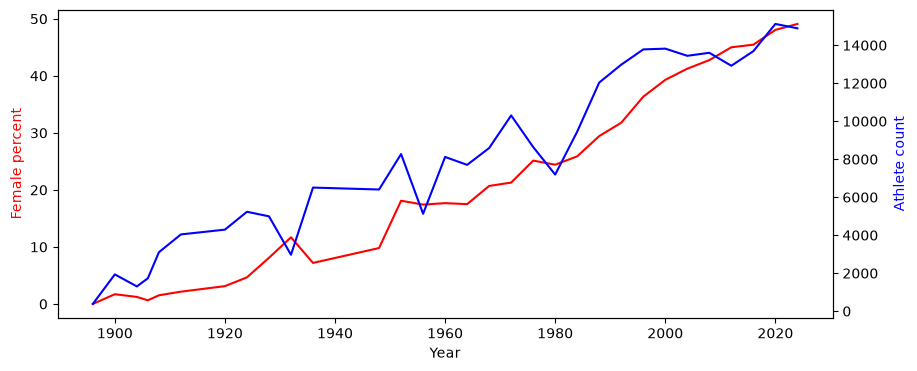

In [46]:
fig, ax1 = plt.subplots(figsize=(10, 4))

sns.lineplot(
    df_gender,
    x="Year",
    y="Female_percent",
    color="red",
    ax=ax1
)
ax1.set_ylabel("Female percent", color="red")

# Prawa oś Y
ax2 = ax1.twinx()

sns.lineplot(data=df_gender, x="Year", y="Athlete_count", color="blue", ax=ax2)

ax2.set_ylabel("Athlete count", color="blue")

plt.show()

In [51]:
df_medal = df[df["Medal"] != "No medal"]
df_medal

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
12,37,Arvo Aaltonen,M,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
13,38,Arvo Aaltonen,M,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
15,41,Paavo Aaltonen,M,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze
16,42,Paavo Aaltonen,M,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold
...,...,...,...,...,...,...,...,...,...,...,...
252551,4979564,Quincy Wilson,M,United States,USA,2024,Summer,Paris,Athletics,4 x 400m Relay Mixed,Silver
252556,4980004,van Anne,F,Netherlands,NED,2024,Summer,Paris,Athletics,Women's 4 x 400m Relay,Silver
252562,1972077,Isayah Boers,M,Netherlands,NED,2024,Summer,Paris,Athletics,4 x 400m Relay Mixed,Gold
252563,1899865,Kevin Staut,M,France,FRA,2024,Summer,Paris,Equestrian,Jumping Team,Bronze


In [79]:
# zasada punktacji medalowej:
# bronze = 1 pkt
# silver = 2 pkt
# gold   = 6 pkt

# liczymy ile kto miał medali w którym roku
df_medal_points = (
    df_medal[["Year", "Team", "Medal", "Sport", "Event"]]
    .drop_duplicates()
    .pivot_table(
        index=["Year", "Team"],
        columns="Medal",
        values="Sport",
        aggfunc="count",
        fill_value=0,
    )
    .reset_index()
)
df_medal_points

Medal,Year,Team,Bronze,Gold,Silver
0,1896,Australia,0,2,0
1,1896,Australia/Great Britain,1,0,0
2,1896,Austria,2,2,1
3,1896,Denmark,3,1,2
4,1896,Ethnikos Gymnastikos Syllogos,1,0,0
...,...,...,...,...,...
1863,2024,Uganda,0,1,1
1864,2024,Ukraine,4,3,5
1865,2024,United States,41,39,42
1866,2024,Uzbekistan,3,8,2


In [80]:
df_medal_points["points"] = (
    6*df_medal_points["Gold"] + 2*df_medal_points["Silver"] + 1*df_medal_points["Bronze"]
) 
df_medal_points

Medal,Year,Team,Bronze,Gold,Silver,points
0,1896,Australia,0,2,0,12
1,1896,Australia/Great Britain,1,0,0,1
2,1896,Austria,2,2,1,16
3,1896,Denmark,3,1,2,13
4,1896,Ethnikos Gymnastikos Syllogos,1,0,0,1
...,...,...,...,...,...,...
1863,2024,Uganda,0,1,1,8
1864,2024,Ukraine,4,3,5,32
1865,2024,United States,41,39,42,359
1866,2024,Uzbekistan,3,8,2,55


In [81]:
df_medal_points_sorted = df_medal_points.sort_values(["Year", "points"], ascending=[True, False])
df_medal_points_sorted

Medal,Year,Team,Bronze,Gold,Silver,points
9,1896,Greece,16,10,16,108
13,1896,United States,2,11,6,80
6,1896,Germany,2,6,5,48
5,1896,France,2,5,4,40
7,1896,Great Britain,2,2,3,20
...,...,...,...,...,...,...
1842,2024,Peru,1,0,0,1
1847,2024,Qatar,1,0,0,1
1852,2024,Singapore,1,0,0,1
1853,2024,Slovakia,1,0,0,1


In [82]:
df_medal_points_sorted['ranking_year'] = df_medal_points_sorted.groupby(["Year"])["points"].rank(
    ascending=False
)
df_medal_points_sorted


Medal,Year,Team,Bronze,Gold,Silver,points,ranking_year
9,1896,Greece,16,10,16,108,1.0
13,1896,United States,2,11,6,80,2.0
6,1896,Germany,2,6,5,48,3.0
5,1896,France,2,5,4,40,4.0
7,1896,Great Britain,2,2,3,20,5.0
...,...,...,...,...,...,...,...
1842,2024,Peru,1,0,0,1,88.5
1847,2024,Qatar,1,0,0,1,88.5
1852,2024,Singapore,1,0,0,1,88.5
1853,2024,Slovakia,1,0,0,1,88.5


In [83]:
df_medal_points_sorted[df_medal_points_sorted["ranking_year"] <= 3]


Medal,Year,Team,Bronze,Gold,Silver,points,ranking_year
9,1896,Greece,16,10,16,108,1.0
13,1896,United States,2,11,6,80,2.0
6,1896,Germany,2,6,5,48,3.0
48,1900,France,22,21,23,194,1.0
96,1900,United States,13,18,14,149,2.0
...,...,...,...,...,...,...,...
1698,2020,China,18,38,32,310,2.0
1729,2020,Japan,17,27,14,207,3.0
1865,2024,United States,41,39,42,359,1.0
1792,2024,China,24,40,27,318,2.0


In [88]:
df_medal_points["ranking_year"] = df_medal_points.groupby(["Year"])["points"].rank(
    ascending=False
)
df_medal_points[df_medal_points["ranking_year"] <= 3].sort_values(["Year", "ranking_year"], ascending=[True, True])

Medal,Year,Team,Bronze,Gold,Silver,points,ranking_year
9,1896,Greece,16,10,16,108,1.0
13,1896,United States,2,11,6,80,2.0
6,1896,Germany,2,6,5,48,3.0
48,1900,France,22,21,23,194,1.0
96,1900,United States,13,18,14,149,2.0
...,...,...,...,...,...,...,...
1698,2020,China,18,38,32,310,2.0
1729,2020,Japan,17,27,14,207,3.0
1865,2024,United States,41,39,42,359,1.0
1792,2024,China,24,40,27,318,2.0


In [77]:
df_medal[
    (df_medal["Year"] == 1976)
    & (df_medal["Team"] == "Poland")
].sort_values("Event").head(50)

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
121154,147649,Bronisaw Malinowski,M,Poland,POL,1976,Summer,Montreal,Athletics,"Athletics Men's 3,000 metres Steeplechase",Silver
88038,106591,Zbigniew Jaremski,M,Poland,POL,1976,Summer,Montreal,Athletics,Athletics Men's 4 x 400 metres Relay,Silver
155314,188661,Jerzy Pietrzyk,M,Poland,POL,1976,Summer,Montreal,Athletics,Athletics Men's 4 x 400 metres Relay,Silver
156709,190357,Ryszard Podlas,M,Poland,POL,1976,Summer,Montreal,Athletics,Athletics Men's 4 x 400 metres Relay,Silver
212712,259088,Jan Werner,M,Poland,POL,1976,Summer,Montreal,Athletics,Athletics Men's 4 x 400 metres Relay,Silver
216272,263300,Jacek Wszoa,M,Poland,POL,1976,Summer,Montreal,Athletics,Athletics Men's High Jump,Gold
183208,223031,Tadeusz Lusarski,M,Poland,POL,1976,Summer,Montreal,Athletics,Athletics Men's Pole Vault,Gold
192237,234312,Irena Szewiska-kirszenstein,F,Poland,POL,1976,Summer,Montreal,Athletics,Athletics Women's 400 metres,Gold
102555,124710,Leszek Kosedowski,M,Poland,POL,1976,Summer,Montreal,Boxing,Boxing Men's Featherweight,Bronze
19706,23664,Leszek Bayski,M,Poland,POL,1976,Summer,Montreal,Boxing,Boxing Men's Flyweight,Bronze


In [85]:
df_medal[df_medal['Name'] == 'Kazimierz Deyna']

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
45865,54599,Kazimierz Deyna,M,Poland,POL,1972,Summer,Munich,Football,Football Men's Football,Gold
45866,54600,Kazimierz Deyna,M,Poland,POL,1976,Summer,Montreal,Football,Football Men's Football,Silver


In [ ]:
df_medal_points['points_max'] = df_medal_points.groupby("Year")["points"].transform("sum")
df_medal_points["points_percent"] = (
    100 * df_medal_points["points"] / df_medal_points["points_max"]
)
df_medal_points

Medal,Year,Team,Bronze,Gold,Silver,points,ranking_year,points_max,points_percent
0,1896,Australia,0,2,0,12,9.0,374,3.208556
1,1896,Australia/Great Britain,1,0,0,1,13.5,374,0.267380
2,1896,Austria,2,2,1,16,7.0,374,4.278075
3,1896,Denmark,3,1,2,13,8.0,374,3.475936
4,1896,Ethnikos Gymnastikos Syllogos,1,0,0,1,13.5,374,0.267380
...,...,...,...,...,...,...,...,...,...
1863,2024,Uganda,0,1,1,8,60.5,2976,0.268817
1864,2024,Ukraine,4,3,5,32,20.0,2976,1.075269
1865,2024,United States,41,39,42,359,1.0,2976,12.063172
1866,2024,Uzbekistan,3,8,2,55,13.5,2976,1.848118


In [95]:
fig = px.area(
    df_medal_points[df_medal_points["Team"] == "Poland"], x="Year", y="points_percent"
)
fig.show()

In [99]:
df_medal[(df_medal["Team"] == "Poland") & (df_medal["Year"] == 1964)]

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
10455,12260,Andrzej Badeski,M,Poland,POL,1964,Summer,Tokyo,Athletics,Athletics Men's 400 metres,Bronze
13478,15808,Waldemar Baszanowski,M,Poland,POL,1964,Summer,Tokyo,Weightlifting,Weightlifting Men's Lightweight,Gold
34995,41807,Teresa Ciepy-wieczorek,F,Poland,POL,1964,Summer,Tokyo,Athletics,Athletics Women's 80 metres Hurdles,Silver
34996,41808,Teresa Ciepy-wieczorek,F,Poland,POL,1964,Summer,Tokyo,Athletics,Athletics Women's 4 x 100 metres Relay,Gold
39969,47547,Krystyna Czajkowska-rawska,F,Poland,POL,1964,Summer,Tokyo,Volleyball,Volleyball Women's Volleyball,Bronze
49878,59357,Marian Dudziak,M,Poland,POL,1964,Summer,Tokyo,Athletics,Athletics Men's 4 x 100 metres Relay,Silver
59098,70789,Marian Foik,M,Poland,POL,1964,Summer,Tokyo,Athletics,Athletics Men's 4 x 100 metres Relay,Silver
60333,72271,Egon Franke,M,Poland,POL,1964,Summer,Tokyo,Fencing,"Fencing Men's Foil, Individual",Gold
60334,72272,Egon Franke,M,Poland,POL,1964,Summer,Tokyo,Fencing,"Fencing Men's Foil, Team",Silver
67575,81082,Marianna (chyliska-),F,Poland,POL,1964,Summer,Tokyo,Volleyball,Volleyball Women's Volleyball,Bronze
